In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA 
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Suppress convergence warnings from statsmodels for cleaner output
warnings.filterwarnings("ignore")

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:
# Load dataset
file_path = "https://raw.githubusercontent.com/josephakpro/Financial_Forecasting/refs/heads/main/Dataset/Processed/processed_financial_forecasting_dataset.csv"
df = pd.read_csv(file_path)

Stationarity Checks (ADF Test) and Differencing

In [7]:
# Checking stationarity and applying first-order differencing to stabilize the mean.
def perform_adf_test(series, title=""):
    print(f"--- ADF Test: {title} ---")
    results = adfuller(series.dropna())
    print(f"ADF Statistic: {results[0]:.4f}")
    print(f"P-value: {results[1]:.4f}")
    print("Critical Values:")
    for key, value in results[4].items():
        print(f"\t{key}: {value:.4f}")
    print("\n")

# Check original series
perform_adf_test(df['Loan Applications'], "Original Loan Applications")

# Apply First Differencing
df['Loan Applications Diff'] = df['Loan Applications'].diff()

# Check differenced series
perform_adf_test(df['Loan Applications Diff'], "First Differenced Loan Applications")

--- ADF Test: Original Loan Applications ---
ADF Statistic: -0.6733
P-value: 0.8535
Critical Values:
	1%: -3.4856
	5%: -2.8857
	10%: -2.5797


--- ADF Test: First Differenced Loan Applications ---
ADF Statistic: -8.9755
P-value: 0.0000
Critical Values:
	1%: -3.4856
	5%: -2.8857
	10%: -2.5797




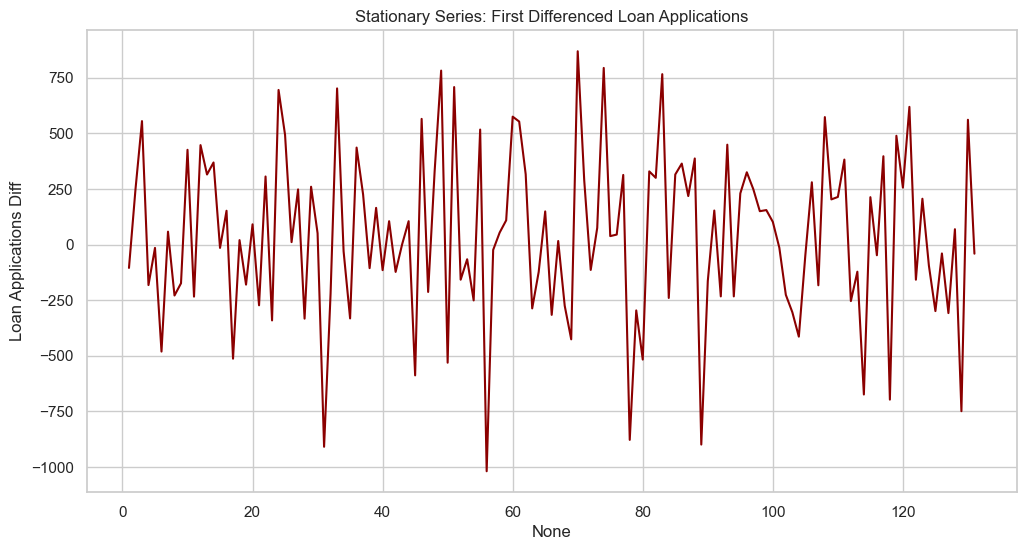

In [8]:
# Plot the stationary series
plt.figure()
sns.lineplot(data=df, x=df.index, y='Loan Applications Diff', color='darkred')
plt.title('Stationary Series: First Differenced Loan Applications')
plt.show()

Autocorrelation (ACF) and Partial Autocorrelation (PACF)

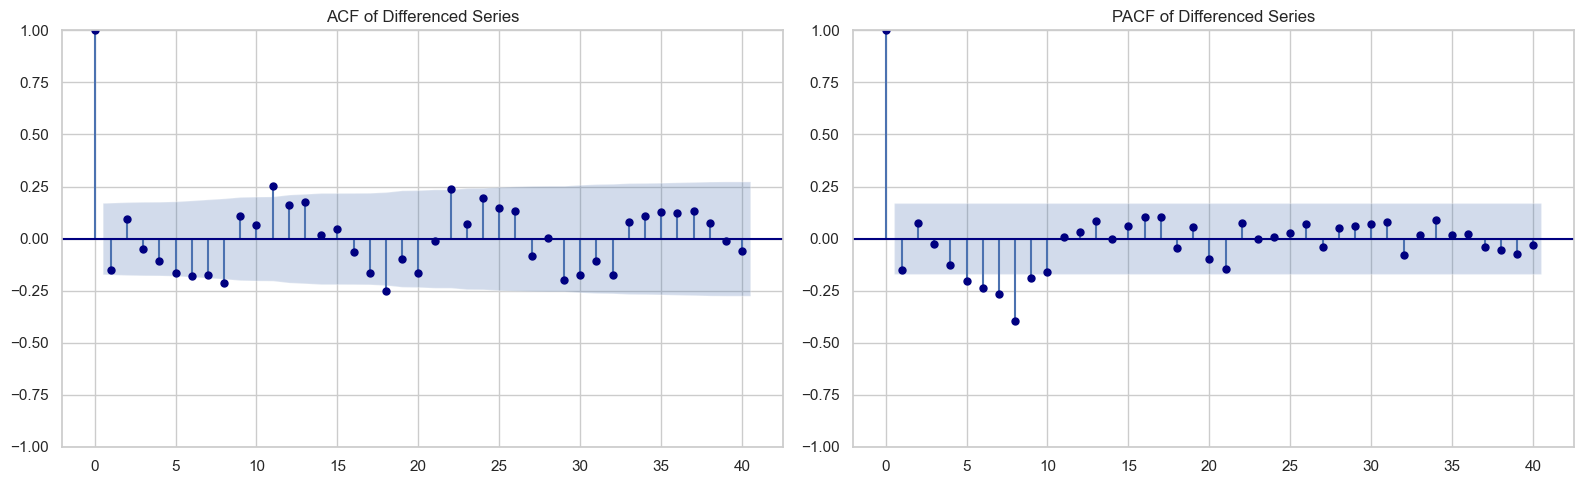

In [9]:
# Drop NA values generated by differencing for ACF/PACF plots
diff_series = df['Loan Applications Diff'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(diff_series, lags=40, ax=ax1, color='navy')
ax1.set_title('ACF of Differenced Series')

plot_pacf(diff_series, lags=40, ax=ax2, color='navy')
ax2.set_title('PACF of Differenced Series')

plt.tight_layout()
plt.show()

Multicollinearity Check

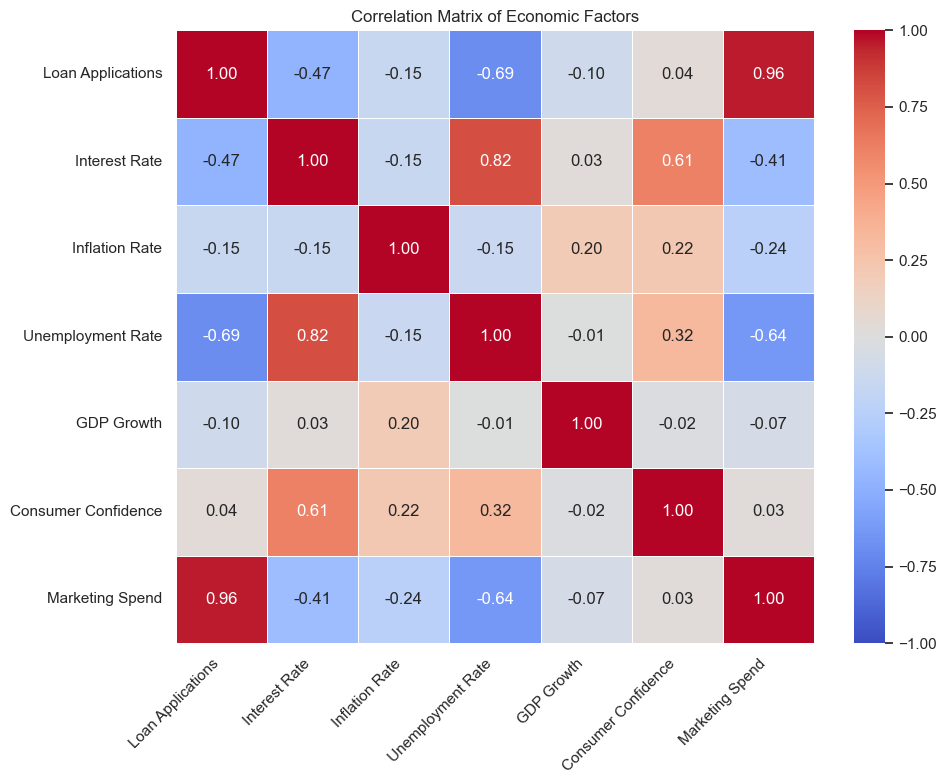

In [11]:
# Checking correlations between exogenous variables to avoid multicollinearity in ARIMAX.

external_factors = ['Interest Rate', 'Inflation Rate', 'Unemployment Rate', 
                    'GDP Growth', 'Consumer Confidence', 'Marketing Spend']

corr = df[['Loan Applications'] + external_factors].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,  
    fmt=".2f",  
    cmap="coolwarm",  
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Correlation Matrix of Economic Factors")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Cross-Validation

In [14]:
# Define exogenous columns
exog_cols = ['Interest Rate', 'Inflation Rate', 'GDP Growth', 'Consumer Confidence', 'Marketing Spend']
# High correlation between Unemployment Rate and Interest Rate. 
# We will remove Unemployment Rate from the ARIMAX features.

# Setup the Expanding Window Split
n_records = len(df)
train_size = int(n_records * 0.8)

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print(f"Training on first {train_size} records. Testing on next {len(test_df)} records...")

# --- Fit Initial Models ONCE ---
# Base ARIMA
model_arima = ARIMA(train_df["Loan Applications"], order=(8, 1, 0))
fitted_arima = model_arima.fit()

# ARIMAX
model_arimax = ARIMA(train_df["Loan Applications"], exog=train_df[exog_cols], order=(8, 1, 0))
fitted_arimax = model_arimax.fit()

# Print Initial Summaries
print("\n--- Initial ARIMAX Summary ---")
print(fitted_arimax.summary().tables[1])

# --- Run Cross-Validation ---
actuals = []
predictions_arima = []
predictions_arimax = []

for i in range(len(test_df)):
    # 1. Forecast 1-step ahead
    fc_arima = fitted_arima.forecast(steps=1)
    predictions_arima.append(fc_arima.values[0])
    
    # Grab current step exog as a 2D array/DataFrame
    current_exog = test_df[exog_cols].iloc[[i]]
    fc_arimax = fitted_arimax.forecast(steps=1, exog=current_exog)
    predictions_arimax.append(fc_arimax.values[0])
    
    # Store Actual Target
    actual_val = test_df["Loan Applications"].iloc[i]
    actuals.append(actual_val)
    
    # 2. Extract raw numpy arrays to prevent statsmodels index validation errors
    # We reshape to (1,) for endog and (1, num_features) for exog
    raw_target = np.array([actual_val])
    raw_exog = current_exog.to_numpy()
    
    # Update the models for the next iteration
    fitted_arima = fitted_arima.extend(raw_target)
    fitted_arimax = fitted_arimax.extend(raw_target, exog=raw_exog)

Training on first 105 records. Testing on next 27 records...

--- Initial ARIMAX Summary ---
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Interest Rate        -168.9555    132.980     -1.271      0.204    -429.591      91.680
Inflation Rate        197.6269     76.201      2.593      0.010      48.276     346.978
GDP Growth             14.1620     57.168      0.248      0.804     -97.885     126.210
Consumer Confidence    34.4343      9.418      3.656      0.000      15.976      52.892
Marketing Spend         0.0092      0.004      2.096      0.036       0.001       0.018
ar.L1                  -0.2991      0.111     -2.703      0.007      -0.516      -0.082
ar.L2                  -0.1189      0.103     -1.150      0.250      -0.321       0.084
ar.L3                  -0.0583      0.100     -0.582      0.561      -0.255       0.138
ar.L4                  -0.1

Model Evaluation and Plotting

--- Cross-Validation Results ---
ARIMA  - RMSE: 306.26 | MAE: 238.71
ARIMAX - RMSE: 311.38 | MAE: 249.21


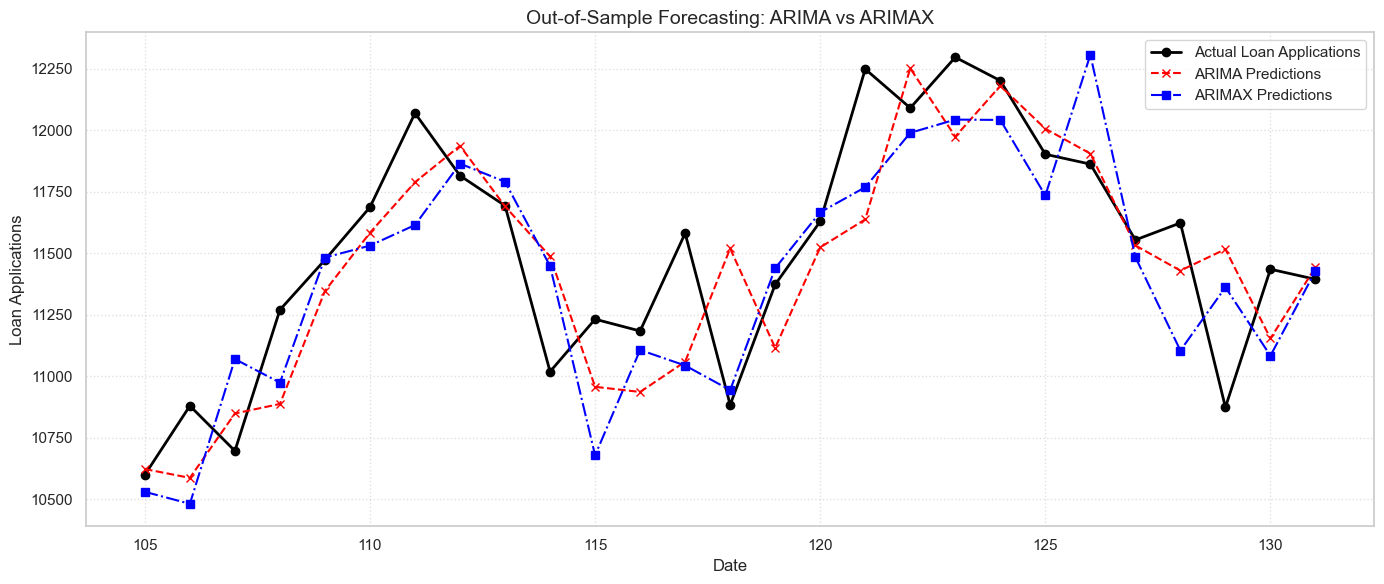

In [15]:
# Calculate Metrics
rmse_arima = np.sqrt(mean_squared_error(actuals, predictions_arima))
mae_arima = mean_absolute_error(actuals, predictions_arima)

rmse_arimax = np.sqrt(mean_squared_error(actuals, predictions_arimax))
mae_arimax = mean_absolute_error(actuals, predictions_arimax)

print("--- Cross-Validation Results ---")
print(f"ARIMA  - RMSE: {rmse_arima:.2f} | MAE: {mae_arima:.2f}")
print(f"ARIMAX - RMSE: {rmse_arimax:.2f} | MAE: {mae_arimax:.2f}")

# Plot Actuals vs Predictions
plt.figure(figsize=(14, 6))
plt.plot(test_df.index, actuals, label='Actual Loan Applications', color='black', marker='o', linewidth=2)
plt.plot(test_df.index, predictions_arima, label='ARIMA Predictions', linestyle='--', color='red', marker='x')
plt.plot(test_df.index, predictions_arimax, label='ARIMAX Predictions', linestyle='-.', color='blue', marker='s')

plt.title("Out-of-Sample Forecasting: ARIMA vs ARIMAX", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Loan Applications")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Metrics Comparison

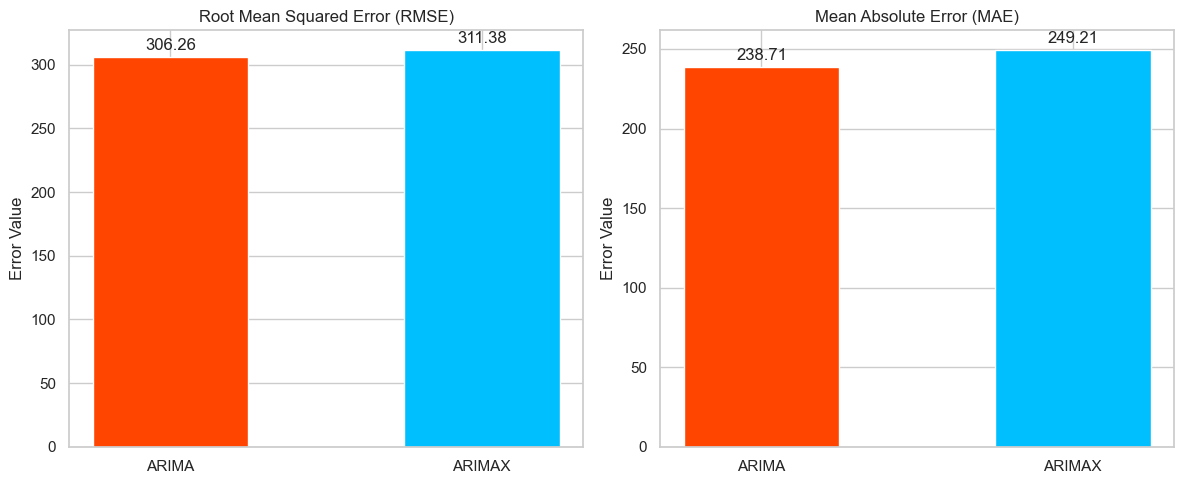

In [16]:
models = ['ARIMA', 'ARIMAX']
rmse_values = [rmse_arima, rmse_arimax]
mae_values = [mae_arima, mae_arimax]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ['orangered', 'deepskyblue']

# RMSE Bar Plot
bars1 = ax1.bar(models, rmse_values, color=colors, width=0.5)
ax1.set_title('Root Mean Squared Error (RMSE)')
ax1.set_ylabel('Error Value')
ax1.bar_label(bars1, padding=3, fmt='%.2f') 

# MAE Bar Plot
bars2 = ax2.bar(models, mae_values, color=colors, width=0.5)
ax2.set_title('Mean Absolute Error (MAE)')
ax2.set_ylabel('Error Value')
ax2.bar_label(bars2, padding=3, fmt='%.2f')

plt.tight_layout()
plt.show()

In [17]:
import pickle

# Save fitted ARIMAX model
with open('forecast_model.pkl', 'wb') as f:
    pickle.dump(fitted_arimax, f)

print("fitted_arimax successfully saved as forecast_model.pkl!")

fitted_arimax successfully saved as forecast_model.pkl!
